# Hangman Solver — TensorFlow Edition

**Author:** Siddhant Kumawat

This notebook consolidates three earlier notebooks into a single, end‑to‑end pipeline:

| Source notebook | What it contributed |
|---|---|
| `hopee.ipynb` | data cleaning, curriculum‑masking scheme, BiLSTM architecture, training loop |
| `finallisma-0-6-0-2-0-2.ipynb` | dual‑model (all‑length / short‑word) inference, statistical priors, information‑gain scoring, fused solver |
| `final-hangman.ipynb` | the official `HangmanAPI` client used to play games against the Trexquant server |

**Framework change:** the original notebooks were written in **PyTorch**. Everything below has been re‑implemented in **TensorFlow / Keras** — the data pipeline, the `HangmanBiLSTM` model, the curriculum training loop (including a hand‑rolled OneCycle learning‑rate schedule), and the inference calls used inside the solver.

> Note: PyTorch checkpoint files (`.pth`) cannot be loaded into a TensorFlow model, so this notebook trains **new** TensorFlow weights from scratch using the same architecture and curriculum described in `hopee.ipynb`, rather than importing the old `.pth` files.

## 0. Setup

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/siddhant-kumawat/allpha/train_words.txt
/kaggle/input/datasets/siddhant-kumawat/allpha/test_words.txt


In [2]:
# ---------- consolidated imports (TensorFlow edition) ----------
import os
import re
import math
import json
import time
import random
import string
import secrets
import collections
from collections import Counter, defaultdict
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import requests
from urllib.parse import parse_qs, urlencode, urlparse
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set()


TensorFlow version: 2.20.0
GPUs available: 2


## 1. Load & clean the training dictionary

Same cleaning rules as `hopee.ipynb`: keep alphabetic words between 3 and 30 characters that contain more than one distinct letter.

In [3]:
DATA_PATH = "/kaggle/input/datasets/siddhant-kumawat/allpha/train_words.txt"

with open(DATA_PATH, "r") as f:
    text = f.read()

words = [line.strip() for line in text.splitlines() if line.strip()]
print(f"Raw word count: {len(words)}")


def clean_word_list(word_list, min_length=3, max_length=30):
    """Filter out unwanted words (too short/long, non‑alphabetic, or single‑letter‑repeat)."""
    cleaned_words = []
    for word in word_list:
        if (
            min_length <= len(word) <= max_length
            and word.isalpha()
            and len(set(word)) > 1
        ):
            cleaned_words.append(word)
    return cleaned_words


clean_words = clean_word_list(words)
print(f"Clean word count: {len(clean_words)}")

# short-word specialist pool (mirrors finallisma's `short_words <= 16`)
short_words = [w for w in clean_words if 0 < len(w) <= 16]
print(f"Short-word pool size (<=16 chars): {len(short_words)}")


Raw word count: 221334
Clean word count: 221334
Short-word pool size (<=16 chars): 217953


## 2. Vocabulary & encoding

TensorFlow's `Embedding(..., mask_zero=True)` treats index **0** as the padding token, so — unlike the PyTorch version, which used index 27 for padding — padding is remapped to `0` here and letters/mask token are shifted up by one. This lets Keras handle masking automatically instead of using `pack_padded_sequence` / `pad_packed_sequence` as the PyTorch code did.

In [4]:
# ----- constants --------------------------------------------------------
CHAR_TO_IDX = {chr(i + 97): i + 1 for i in range(26)}   # 'a'-'z' -> 1-26
CHAR_TO_IDX['_'] = 27                                    # mask/blank token
PAD_IDX, MASK_IDX = 0, 27
VOCAB_SIZE = 28                                          # pad + 26 letters + blank
MAX_LEN = 30

IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}


def encode_word(word: str, max_len: int = MAX_LEN) -> List[int]:
    """Right-pad / truncate a (possibly masked) word to `max_len`."""
    enc = [CHAR_TO_IDX.get(c, PAD_IDX) for c in word.lower()]
    enc = (enc + [PAD_IDX] * max_len)[:max_len]
    return enc


## 3. Curriculum masking utilities

Ported directly from `hopee.ipynb` (`generate_partial_mask` / `CurriculumHangmanDataset._add_mask`). Given a word, we blank out a random number of letters (between `min_mask` and `max_mask`) and pick one of the blanked letters as the training target — exactly like a mid‑game Hangman board.

In [5]:
def add_mask(word: str, min_mask: int = 1, max_mask: int = 1) -> Tuple[str, List[str]]:
    """Blank between `min_mask` and `max_mask` characters of `word`.

    Returns (masked_word, list_of_hidden_letters). Defensive against the
    edge case where masking accidentally produces zero hidden letters.
    """
    n_maskable = max(1, len(word) - 1)          # always leave >=1 letter visible
    lo = min(min_mask, n_maskable)
    hi = min(max_mask, n_maskable)
    hi = max(hi, lo)
    n_masks = random.randint(lo, hi)
    idxs = random.sample(range(len(word)), n_masks)

    masked, hidden = list(word), []
    for i in idxs:
        hidden.append(word[i])
        masked[i] = '_'

    if not hidden:                               # should not happen, but stay safe
        masked[0], hidden = '_', [word[0]]

    return ''.join(masked), hidden


def generate_partial_mask(word, min_mask=1, max_mask=None):
    """Kept for parity with the original notebook's helper name/signature."""
    eff_max = max_mask if max_mask is not None else len(word) - 1
    return add_mask(word, min_mask, eff_max)


def generate_training_samples(word, n_samples=4, min_mask=1, max_mask=None):
    samples = []
    for _ in range(n_samples):
        masked, hidden_chars = generate_partial_mask(word, min_mask, max_mask)
        if hidden_chars:
            samples.append((masked, hidden_chars))
    return samples


# sanity check
print(generate_partial_mask('trexquant'))
print(generate_training_samples('dubey'))


('_rex_uant', ['t', 'q'])
[('d_be_', ['u', 'y']), ('dube_', ['y']), ('dube_', ['y']), ('_u___', ['d', 'y', 'e', 'b'])]


## 4. Vectorized batch builder (fast path)

Replaces the earlier `tf.data.Dataset.from_generator` pipeline. `from_generator` calls a Python generator **one example at a time** under the GIL — a known slow path. `make_batch` instead builds an entire batch as NumPy/TF tensors in a single call, and — combined with floor‑division `steps_per_epoch` in Section 7 — guarantees every batch has an **identical, fixed shape**. Fixed shapes let `@tf.function` trace the training step **once** and reuse that compiled graph for the rest of training, instead of retracing whenever a shape changes.

In [6]:
def make_batch(batch_words: List[str], min_mask: int, max_mask: int):
    """Build one full training batch as (x, lengths, y) tensors in a single call.

    Avoids the per-example Python/GIL overhead of tf.data.Dataset.from_generator,
    and keeps every batch's shape identical -- required for fast, single-trace
    @tf.function execution.
    """
    xs, lens, ys = [], [], []
    for w in batch_words:
        masked, hidden = add_mask(w, min_mask, max_mask)
        xs.append(encode_word(masked))
        lens.append(min(len(w), MAX_LEN))
        ys.append(ord(random.choice(hidden)) - 97)   # class index 0-25 ('a'-'z')

    x = tf.constant(xs, dtype=tf.int32)
    lengths = tf.constant(lens, dtype=tf.int32)
    y = tf.constant(ys, dtype=tf.int32)
    return x, lengths, y


# quick smoke test
_x, _l, _y = make_batch(['mohit', 'assy', 'arijit', 'sreya'], min_mask=1, max_mask=1)
print(_x.shape, _l.shape, _y.shape)


(4, 30) (4,) (4,)


I0000 00:00:1787987849.278754      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787987849.284847      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 5. Model — Bidirectional LSTM

Direct TensorFlow port of the PyTorch `HangmanBiLSTM`:

* `nn.Embedding(..., padding_idx=PAD_IDX)` → `layers.Embedding(..., mask_zero=True)`
* `nn.LSTM(..., bidirectional=True)` stacked `num_layers` times → a list of `layers.Bidirectional(layers.LSTM(...))`
* `pack_padded_sequence` / `pad_packed_sequence` + manual gather of the last valid timestep → Keras mask propagation + `tf.gather_nd` on `lengths - 1`
* `nn.Linear(hidden*2, 26)` → `layers.Dense(26)`

In [7]:
class HangmanBiLSTM(keras.Model):
    def __init__(self, vocab_size=VOCAB_SIZE, emb_dim=64, hidden_dim=128, num_layers=2, **kwargs):
        super().__init__(**kwargs)
        self.embedding = layers.Embedding(vocab_size, emb_dim, mask_zero=True)
        self.lstm_layers = [
            layers.Bidirectional(layers.LSTM(hidden_dim, return_sequences=True))
            for _ in range(num_layers)
        ]
        self.classifier = layers.Dense(26)

    def call(self, x, lengths, training=False):
        mask = self.embedding.compute_mask(x)
        h = self.embedding(x)
        for lstm in self.lstm_layers:
            h = lstm(h, mask=mask, training=training)

        # gather the hidden state at each sample's true last valid timestep
        batch_idx = tf.range(tf.shape(h)[0])
        last_idx = tf.cast(lengths, tf.int32) - 1
        last_idx = tf.clip_by_value(last_idx, 0, tf.shape(h)[1] - 1)
        gather_idx = tf.stack([batch_idx, last_idx], axis=1)
        final = tf.gather_nd(h, gather_idx)

        return self.classifier(final)


def build_model(**kwargs):
    """kwargs forwarded to HangmanBiLSTM, e.g. build_model(hidden_dim=256)."""
    model = HangmanBiLSTM(**kwargs)
    # build weights with a dummy forward pass
    dummy_x = tf.zeros((1, MAX_LEN), dtype=tf.int32)
    dummy_len = tf.constant([1], dtype=tf.int32)
    _ = model(dummy_x, dummy_len, training=False)
    return model


test_model = build_model(hidden_dim=256)
test_model.summary()


Model: "hangman_bi_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 30, 64)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (1, 30, 512)           │       657,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (1, 30, 512)           │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 26)                │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247,450 (8.57 MB)

 Trainable params: 2,247,450 (8.57 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Learning‑rate schedule — `CosineDecay` (in‑graph)

The original hand‑rolled `one_cycle_lr()` had to be evaluated in Python and pushed into the optimizer with an eager `optimizer.learning_rate.assign(lr)` call **every single step** — a host round‑trip that also makes the step incompatible with clean `@tf.function` tracing.

`keras.optimizers.schedules.CosineDecay` fixes this: it's a `Callable` the optimizer evaluates **internally**, using its own `iterations` counter, entirely inside the compiled graph. No Python-side LR bookkeeping, no per-step `.assign()`, no host round-trip.

In [8]:
def make_lr_schedule(max_lr: float, epochs: int, steps_per_epoch: int):
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=max_lr,
        decay_steps=epochs * steps_per_epoch,
    )


## 7. Curriculum training loop (fast, `@tf.function`‑compiled)

Rewritten to match the faster pattern:

* **`@tf.function`‑compiled `train_step`** — traced into a static graph once, then replayed with no per‑op Python dispatch overhead (the single biggest speedup vs. the original eager loop).
* **In‑graph `CosineDecay` schedule** baked straight into the `AdamW` optimizer (Section 6) — no eager `.assign()` calls.
* **In‑graph gradient clipping** via `AdamW(..., clipnorm=1.0)` instead of a separate `tf.clip_by_global_norm` call every step.
* **Vectorized `make_batch`** (Section 4) instead of a `tf.data` generator, with `steps_per_epoch = len(words) // batch_size` (floor division) so every batch has an identical, fixed shape and `train_step` never needs to retrace.

The curriculum schedule (easy → medium → hard masking) is unchanged from the original loop.

In [9]:
def train_model(word_list: List[str], run_name: str, epochs: int = 100, batch_size: int = 512,
                 max_lr: float = 3e-3, weight_decay: float = 1e-4,
                 hidden_dim: int = 128, emb_dim: int = 64, num_layers: int = 2):

    steps_per_epoch = len(word_list) // batch_size          # floor division -> fixed batch shapes
    lr_schedule = make_lr_schedule(max_lr, epochs, steps_per_epoch)

    model = build_model(hidden_dim=hidden_dim, emb_dim=emb_dim, num_layers=num_layers)
    optimizer = keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=weight_decay, clipnorm=1.0)
    loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    @tf.function
    def train_step(x, lengths, y):
        with tf.GradientTape() as tape:
            logits = model(x, lengths, training=True)
            loss = loss_fn(y, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        pred = tf.argmax(logits, axis=1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(pred == y, tf.float32))
        return loss, acc

    history = {'lr': [], 'mask_lo': [], 'epoch_loss': [], 'epoch_acc': []}
    y_true_all, y_pred_all = [], []
    words = list(word_list)      # local shuffle copy -- doesn't mutate the caller's list

    for epoch in range(epochs):
        # ----- curriculum schedule (same breakpoints as before) -----
        if epoch < 0.4 * epochs:
            lo, hi = 1, 1
        elif epoch < 0.8 * epochs:
            lo, hi = 1, 4
        else:
            lo, hi = 2, 6

        random.shuffle(words)
        epoch_loss, epoch_acc, n_batches = 0.0, 0.0, 0

        for step in range(steps_per_epoch):
            batch_words = words[step * batch_size:(step + 1) * batch_size]
            x, lengths, y = make_batch(batch_words, lo, hi)

            loss, acc = train_step(x, lengths, y)
            epoch_loss += float(loss)
            epoch_acc += float(acc)
            n_batches += 1

            history['lr'].append(float(lr_schedule(optimizer.iterations)))
            history['mask_lo'].append(lo)

            if epoch == epochs - 1:               # collect confusion-matrix stats on last epoch
                logits = model(x, lengths, training=False)
                preds = tf.argmax(logits, axis=1, output_type=tf.int32)
                y_true_all.extend(y.numpy().tolist())
                y_pred_all.extend(preds.numpy().tolist())

        epoch_loss /= n_batches
        epoch_acc /= n_batches
        history['epoch_loss'].append(epoch_loss)
        history['epoch_acc'].append(epoch_acc)

        print(f"[{run_name}] Epoch {epoch+1:3d}/{epochs} | loss {epoch_loss:.4f} | "
              f"acc {epoch_acc:6.2%} | mask[{lo},{hi}]")

    return model, history, (y_true_all, y_pred_all)


### 7a. Train the full‑length model (`model_all`)

Trained on every cleaned word, regardless of length — mirrors `best_hangman_bilstm.pth` from `finallisma-0-6-0-2-0-2.ipynb`.

> Reduce `EPOCHS` for a quicker smoke‑test run; the original PyTorch notebook trained for 100 epochs.

In [10]:
EPOCHS = 100
BATCH = 512
HIDDEN_DIM = 256          # both model_all and model_short now use 256 hidden units

model_all, history_all, (y_true_all_last, y_pred_all_last) = train_model(
    clean_words, run_name="model_all", epochs=EPOCHS, batch_size=BATCH, hidden_dim=HIDDEN_DIM
)

os.makedirs("/kaggle/working", exist_ok=True)
model_all.save_weights("/kaggle/working/model_all.weights.h5")
print("Saved model_all weights -> /kaggle/working/model_all.weights.h5")


[model_all] Epoch   1/100 | loss 2.2371 | acc 28.25% | mask[1,1]
[model_all] Epoch   2/100 | loss 1.7737 | acc 41.95% | mask[1,1]
[model_all] Epoch   3/100 | loss 1.6047 | acc 47.43% | mask[1,1]
[model_all] Epoch   4/100 | loss 1.5075 | acc 50.51% | mask[1,1]
[model_all] Epoch   5/100 | loss 1.4316 | acc 53.17% | mask[1,1]
[model_all] Epoch   6/100 | loss 1.3769 | acc 55.08% | mask[1,1]
[model_all] Epoch   7/100 | loss 1.3320 | acc 56.61% | mask[1,1]
[model_all] Epoch   8/100 | loss 1.2863 | acc 58.11% | mask[1,1]
[model_all] Epoch   9/100 | loss 1.2529 | acc 59.31% | mask[1,1]
[model_all] Epoch  10/100 | loss 1.2279 | acc 60.08% | mask[1,1]
[model_all] Epoch  11/100 | loss 1.1991 | acc 61.03% | mask[1,1]
[model_all] Epoch  12/100 | loss 1.1756 | acc 61.81% | mask[1,1]
[model_all] Epoch  13/100 | loss 1.1572 | acc 62.47% | mask[1,1]
[model_all] Epoch  14/100 | loss 1.1345 | acc 63.10% | mask[1,1]
[model_all] Epoch  15/100 | loss 1.1204 | acc 63.66% | mask[1,1]
[model_all] Epoch  16/100

### 7b. Train the short‑word specialist (`model_short`)

Trained only on words of length ≤16 — mirrors `snapshot_epoch600.pth` from `finallisma-0-6-0-2-0-2.ipynb`.

In [11]:
model_short, history_short, (y_true_short_last, y_pred_short_last) = train_model(
    short_words, run_name="model_short", epochs=EPOCHS, batch_size=BATCH, hidden_dim=HIDDEN_DIM
)

model_short.save_weights("/kaggle/working/model_short.weights.h5")
print("Saved model_short weights -> /kaggle/working/model_short.weights.h5")


[model_short] Epoch   1/100 | loss 2.2677 | acc 27.11% | mask[1,1]
[model_short] Epoch   2/100 | loss 1.7971 | acc 41.35% | mask[1,1]
[model_short] Epoch   3/100 | loss 1.6233 | acc 46.83% | mask[1,1]
[model_short] Epoch   4/100 | loss 1.5153 | acc 50.26% | mask[1,1]
[model_short] Epoch   5/100 | loss 1.4508 | acc 52.55% | mask[1,1]
[model_short] Epoch   6/100 | loss 1.3884 | acc 54.69% | mask[1,1]
[model_short] Epoch   7/100 | loss 1.3408 | acc 56.12% | mask[1,1]
[model_short] Epoch   8/100 | loss 1.3062 | acc 57.46% | mask[1,1]
[model_short] Epoch   9/100 | loss 1.2688 | acc 58.57% | mask[1,1]
[model_short] Epoch  10/100 | loss 1.2418 | acc 59.48% | mask[1,1]
[model_short] Epoch  11/100 | loss 1.2125 | acc 60.62% | mask[1,1]
[model_short] Epoch  12/100 | loss 1.1956 | acc 61.24% | mask[1,1]
[model_short] Epoch  13/100 | loss 1.1687 | acc 62.06% | mask[1,1]
[model_short] Epoch  14/100 | loss 1.1478 | acc 62.81% | mask[1,1]
[model_short] Epoch  15/100 | loss 1.1308 | acc 63.32% | mask[

### 7c. Save & reload pretrained weights

Weights for both models are already saved to `/kaggle/working/` right after each training run above (`model_all.weights.h5`, `model_short.weights.h5`).

This cell lets you **skip retraining entirely** on a later run: set `LOAD_PRETRAINED = True` and point the paths at your saved weight files — either ones still sitting in `/kaggle/working/` from an earlier version of this same notebook, or files you've attached as a Kaggle Dataset input from a previous run. The model architecture (`hidden_dim`, `emb_dim`, `num_layers`) **must exactly match** what was used during training, otherwise `load_weights` will raise a shape-mismatch error — that's why `HIDDEN_DIM` is reused here rather than hardcoded again.

In [ ]:
def load_pretrained_model(weights_path, hidden_dim=256, emb_dim=64, num_layers=2, vocab_size=VOCAB_SIZE):
    """
    Rebuild the HangmanBiLSTM architecture and load previously-saved weights
    from disk. Architecture must match exactly what was used for training
    (hidden_dim/emb_dim/num_layers), otherwise load_weights raises a
    shape-mismatch error.
    """
    model = build_model(vocab_size=vocab_size, emb_dim=emb_dim, hidden_dim=hidden_dim, num_layers=num_layers)
    model.load_weights(weights_path)
    print(f"Loaded pretrained weights from {weights_path}")
    return model


# ----------------------------------------------------------------------
# Set this to True to skip Sections 7a/7b entirely and reload previously
# trained + saved weights instead (e.g. on a re-run, or weights attached
# as a Kaggle Dataset input from an earlier training run).
# ----------------------------------------------------------------------
LOAD_PRETRAINED = True
MODEL_ALL_WEIGHTS_PATH = "/kaggle/working/model_all.weights.h5"
MODEL_SHORT_WEIGHTS_PATH = "/kaggle/working/model_short.weights.h5"

if LOAD_PRETRAINED:
    model_all = load_pretrained_model(MODEL_ALL_WEIGHTS_PATH, hidden_dim=HIDDEN_DIM)
    model_short = load_pretrained_model(MODEL_SHORT_WEIGHTS_PATH, hidden_dim=HIDDEN_DIM)
    print("Using pretrained weights -- training skipped, model_all/model_short reloaded from disk.")
else:
    print("LOAD_PRETRAINED is False -- using the freshly trained model_all/model_short from Sections 7a/7b above.")


## 8. Diagnostics / plots

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_all['epoch_loss'], label='model_all')
axes[0].plot(history_short['epoch_loss'], label='model_short')
axes[0].set_title('Training loss per epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_all['epoch_acc'], label='model_all')
axes[1].plot(history_short['epoch_acc'], label='model_short')
axes[1].set_title('Training accuracy per epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()


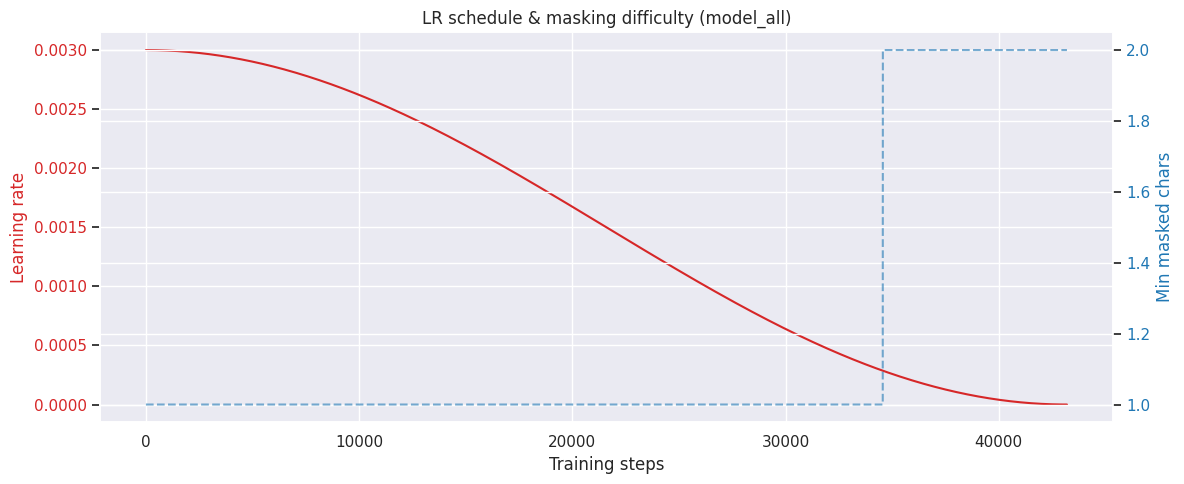

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:red'
ax1.set_xlabel('Training steps')
ax1.set_ylabel('Learning rate', color=color)
ax1.plot(history_all['lr'], color=color, label='LR')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('LR schedule & masking difficulty (model_all)')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Min masked chars', color=color)
ax2.plot(history_all['mask_lo'], color=color, alpha=0.6, ls='--', label='Curriculum min-mask')
ax2.tick_params(axis='y', labelcolor=color)

plt.tight_layout()
plt.show()


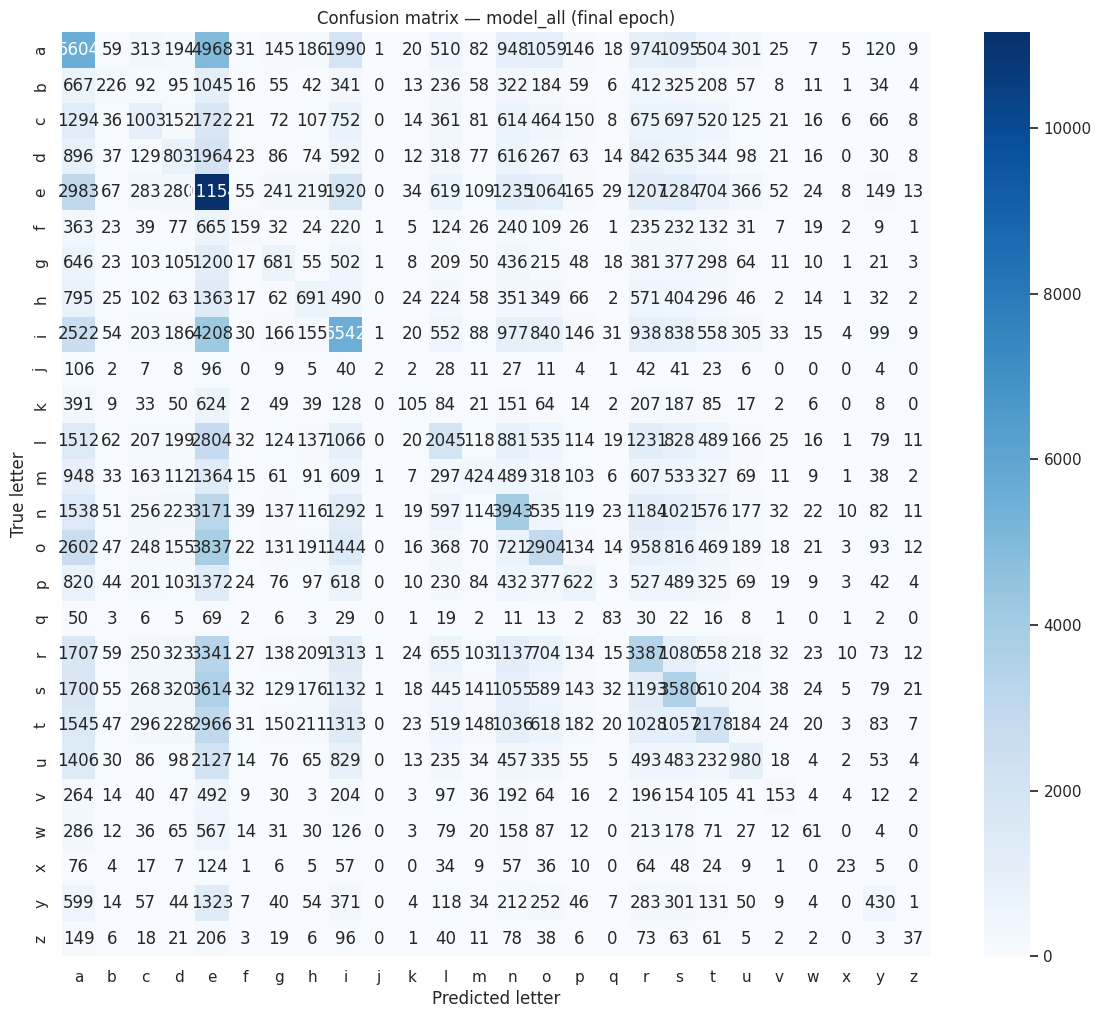

In [15]:
labels = [chr(97 + i) for i in range(26)]
cm = confusion_matrix(y_true_all_last, y_pred_all_last, labels=range(26))

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion matrix — model_all (final epoch)')
plt.xlabel('Predicted letter'); plt.ylabel('True letter')
plt.show()


## 9. Statistical language priors & information gain

Framework‑independent (pure Python), unchanged from `finallisma-0-6-0-2-0-2.ipynb`. These provide a non‑neural backstop signal (unigram/bigram frequency + information gain over the candidate word set) that gets fused with the BiLSTM's predictions.

In [16]:
# ── Unigram & bigram priors (short words only) ─────────────────────────────
uni_cnt = Counter("".join(short_words))
total_u = sum(uni_cnt.values())
P_uni = {ch: uni_cnt[ch] / total_u for ch in string.ascii_lowercase}

bi_cnt = Counter((a, b) for w in short_words for a, b in zip(w, w[1:]))
total_b = sum(bi_cnt.values())
P_bi = {bg: bi_cnt[bg] / total_b for bg in bi_cnt}


def compute_conditional_prior(candidates):
    cnt = Counter("".join(candidates))
    tot = sum(cnt.values())
    if tot == 0:
        return {ch: 0.0 for ch in string.ascii_lowercase}
    return {ch: cnt[ch] / tot for ch in string.ascii_lowercase}


def compute_info_gain(candidates):
    C = len(candidates)
    if C == 0:
        return {ch: 0.0 for ch in string.ascii_lowercase}
    mem = defaultdict(int)
    for w in candidates:
        for ch in set(w):
            mem[ch] += 1
    ig = {}
    for ch in string.ascii_lowercase:
        yes = mem[ch]
        no = C - yes
        py, pn = yes / C, no / C
        val = 0.0
        if py > 0:
            val += py * (math.log2(C) - math.log2(yes))
        if pn > 0 and no > 0:
            val += pn * (math.log2(C) - math.log2(no))
        ig[ch] = val
    return ig


print("Priors & info-gain helpers ready.")


Priors & info-gain helpers ready.


## 10. Manual offline tester — local Hangman simulator (no API)

Everything below runs **entirely offline** — no calls to the Trexquant server. It:

* reimplements the win/loss and tries‑remaining bookkeeping yourself with explicit `if` / `else` conditions (standard rules: **6 wrong guesses allowed**, same as the live game)
* reuses the exact same model‑fusion logic as `MyHangmanSolver.guess()` from Section 11 below (BiLSTM probability + statistical prior + information gain), just refactored into a plain function so it doesn't need an active `HangmanAPI` session
* plays a batch of games over a random sample of words from your dataset and reports a win/loss table you can inspect directly in the notebook

This is meant purely for **local testing/debugging** of the guessing strategy before you ever spend a real game against the server.

In [17]:
def local_guess_letter(pattern, guessed_letters, model_all, model_short, short_words,
                        P_uni, P_bi, alpha=0.8, beta=0.0, gamma=0.2,
                        w1=0.3, w2=0.2, w3=0.5):
    """
    Choose the next letter to guess given the current masked pattern
    (e.g. '_pp_e') and the set of letters already guessed.

    This is the same fusion logic as MyHangmanSolver.guess() (BiLSTM
    probability + unigram/bigram statistical prior + information gain),
    pulled out into a standalone function so it can run without an active
    HangmanAPI/network session — useful for fast local simulation.
    """
    pattern = pattern.lower()
    L = len(pattern)

    VOWELS = sorted(list("eaiou"), key=lambda c: -P_uni[c])
    CONSONANTS = [c for c in string.ascii_lowercase if c not in VOWELS]
    CONSONANTS.sort(key=lambda c: -P_uni[c])

    # tiny-word fallback
    if L <= 3:
        for ch in VOWELS:
            if ch not in guessed_letters:
                return ch
        for ch in CONSONANTS:
            if ch not in guessed_letters:
                return ch
        return "e"

    # candidate words consistent with the current pattern
    cands = [
        w for w in short_words
        if len(w) == L
        and all(pc == "_" or pc == wc for pc, wc in zip(pattern, w))
    ]

    net = model_all if L > 16 else model_short
    x_in = tf.constant([encode_word(pattern, MAX_LEN)], dtype=tf.int32)
    l_in = tf.constant([L], dtype=tf.int32)
    logits = net(x_in, l_in, training=False)
    probs = tf.nn.softmax(logits, axis=1).numpy()[0]
    model_p = {string.ascii_lowercase[i]: probs[i] for i in range(26)}

    stat_scores = {}
    if L <= 16:
        cp = compute_conditional_prior(cands)
        for ch in string.ascii_lowercase:
            if ch in guessed_letters:
                continue
            s1 = P_uni.get(ch, 0.0)
            bs = []
            for i, pc in enumerate(pattern):
                if pc == "_":
                    lp = pattern[i - 1] if i > 0 else None
                    rp = pattern[i + 1] if i < L - 1 else None
                    if lp and lp != "_":
                        bs.append(P_bi.get((lp, ch), 0.0))
                    if rp and rp != "_":
                        bs.append(P_bi.get((ch, rp), 0.0))
            s2 = sum(bs) / len(bs) if bs else 0.0
            s3 = cp.get(ch, 0.0)
            stat_scores[ch] = (
                w1 * math.log(s1 + 1e-12)
                + w2 * math.log(s2 + 1e-12)
                + w3 * math.log(s3 + 1e-12)
            )

    ig_scores = compute_info_gain(cands) if L <= 16 else {}

    best_score, best_ch = -1e9, None
    for ch in string.ascii_lowercase:
        if ch in guessed_letters:
            continue
        m = math.log(model_p.get(ch, 1e-12))
        st = stat_scores.get(ch, 0.0)
        ig = ig_scores.get(ch, 0.0)
        score = alpha * m + (1 - alpha) * (beta * st + gamma * ig)
        if score > best_score:
            best_score, best_ch = score, ch

    return best_ch


### 10a. Local game loop — manual tries tracking

In [ ]:
def play_local_game(secret_word, max_tries=6, verbose=True, **guess_kwargs):
    """
    Play one offline Hangman game against the trained models.

    Standard rules: `max_tries` wrong guesses allowed (default 6, same as
    the live server). Win/loss and the tries counter are tracked manually
    with explicit if/else conditions rather than any built-in game engine.
    """
    secret_word = secret_word.lower()
    guessed_letters = set()
    revealed = ['_'] * len(secret_word)
    tries_remaining = max_tries
    n_guesses = 0

    while True:
        current_pattern = ''.join(revealed)

        # ----- win condition -----
        if '_' not in current_pattern:
            if verbose:
                print(f"WON  -> '{secret_word}'  (guesses used: {n_guesses}, tries left: {tries_remaining})")
            return {
                'word': secret_word, 'length': len(secret_word), 'result': 'WIN',
                'tries_used': max_tries - tries_remaining, 'n_guesses': n_guesses,
                'guessed_letters': ''.join(sorted(guessed_letters)),
            }

        # ----- loss condition -----
        if tries_remaining <= 0:
            if verbose:
                print(f"LOST -> '{secret_word}'  (revealed: {current_pattern})")
            return {
                'word': secret_word, 'length': len(secret_word), 'result': 'LOSS',
                'tries_used': max_tries, 'n_guesses': n_guesses,
                'guessed_letters': ''.join(sorted(guessed_letters)),
            }

        # ----- pick next letter -----
        guess_letter = local_guess_letter(current_pattern, guessed_letters, **guess_kwargs)
        guessed_letters.add(guess_letter)
        n_guesses += 1

        # ----- manual tries bookkeeping -----
        if guess_letter in secret_word:
            for i, ch in enumerate(secret_word):
                if ch == guess_letter:
                    revealed[i] = ch
            if verbose:
                print(f"  guess '{guess_letter}' -> HIT   | {''.join(revealed)}")
        else:
            tries_remaining -= 1
            if verbose:
                print(f"  guess '{guess_letter}' -> MISS  | tries left: {tries_remaining}")


In [ ]:
# ---- Held-out test set (for genuine unseen-word evaluation in Section 10) ----
TEST_DATA_PATH = "/kaggle/input/datasets/siddhant-kumawat/allpha/test_words.txt"

with open(TEST_DATA_PATH, "r") as f:
    text = f.read()
test_words_raw = [line.strip() for line in text.splitlines() if line.strip()]
print(f"Raw held-out word count: {len(test_words_raw)}")

test_words = clean_word_list(test_words_raw)   # reuses the same clean_word_list() you already defined
print(f"Clean held-out test word count: {len(test_words)}")

### 10b. Single-game demo (verbose)

In [ ]:
demo_word = random.choice(clean_words)
print(f"Demo game -- secret word: '{demo_word}'\n")

_ = play_local_game(
    demo_word, max_tries=6, verbose=True,
    model_all=model_all, model_short=model_short, short_words=short_words,
    P_uni=P_uni, P_bi=P_bi,
)


### 10c. Batch test on sample data

In [ ]:
random.seed(123)
test_sample = test_words                 # use the full held-out split, not a sample of training words

results = []
for w in test_sample:
    res = play_local_game(
        w, max_tries=6, verbose=False,
        model_all=model_all, model_short=model_short, short_words=short_words,
        P_uni=P_uni, P_bi=P_bi,
    )
    results.append(res)

results_df = pd.DataFrame(results)
results_df.head(10)


In [ ]:
win_rate = (results_df['result'] == 'WIN').mean()
avg_guesses_win = results_df.loc[results_df['result'] == 'WIN', 'n_guesses'].mean()
avg_tries_used = results_df['tries_used'].mean()

print(f"Games played         : {len(results_df)}")
print(f"Wins                 : {(results_df['result']=='WIN').sum()}")
print(f"Losses               : {(results_df['result']=='LOSS').sum()}")
print(f"Win rate             : {win_rate:.2%}")
print(f"Avg guesses on wins  : {avg_guesses_win:.2f}")
print(f"Avg wrong tries used : {avg_tries_used:.2f} / 6")


### 10d. Win rate by word length

In [ ]:
by_len = results_df.groupby('length')['result'].apply(lambda s: (s == 'WIN').mean())

plt.figure(figsize=(12, 5))
by_len.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Local test -- win rate by word length')
plt.xlabel('Word length'); plt.ylabel('Win rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Recorded games

⚠️ Running the cell below finalizes your official submission — once it completes successfully, subsequent runs will fail with "Your account has been deactivated." Only run this after you are fully satisfied with the solver's practice performance.

In [ ]:
# for i in range(1000):
#     print(f"Playing recorded game {i + 1}")
#     api.start_game(practice=0, verbose=True)

# recorded_stats = api.my_status()
# print(recorded_stats)
